 # Step 1: Load and Clean the Dataset

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("C://Applied Project/healthcare_dataset.csv",sep=';')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (20000, 16)


,Country,City,Hospital,Gender,Age,Blood Type,Medical Condition,Medication,Date of Admission,Discharge Date,Stay Duration,Test Results,Insurance Provider,Billing Amount (Local),Billing Currency,Billing Amount (EUR)
0,India,Kolkata,AIIMS Delhi,Male,32,B+,Hypertension,Lisinopril,15/04/2023,27/04/2023,12,Positive,ICICI Lombard,2976,INR,32.74
1,India,Chennai,AIIMS Delhi,Female,29,AB+,Tuberculosis,Rifampin,07/01/2023,21/01/2023,14,Positive,ICICI Lombard,11105,INR,122.15
2,India,Delhi,AIIMS Delhi,Other,45,AB+,Asthma,Fluticasone,14/02/2023,27/02/2023,13,Negative,Ayushman Bharat,4582,INR,50.40
3,India,Bangalore,Fortis Mumbai,Male,85,AB+,Cancer,Cisplatin,23/03/2023,07/04/2023,15,Positive,Ayushman Bharat,11108,INR,122.19
4,India,Bangalore,Apollo Chennai,Other,90,A-,Diabetes,Insulin,15/09/2024,27/09/2024,12,Positive,Star Health,17147,INR,188.62


In [7]:
# Convert date fields 
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], dayfirst=True, errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], dayfirst=True, errors='coerce')


# Calculate stay duration and validate
df['Calculated Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Stay Duration Check'] = df['Calculated Stay'] == df['Stay Duration']
df['Stay Duration Check'].value_counts()


Stay Duration Check
True    20000
Name: count, dtype: int64

In [9]:
# Save cleaned dataset
df.to_csv("C://Applied Project/cleaned_regenerated_healthcare_dataset.csv", index=False)


# Step 2: Exploratory Data Analysis (EDA)

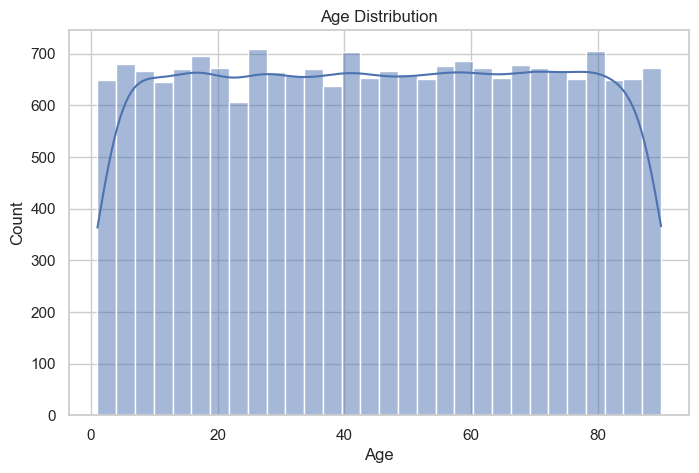

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


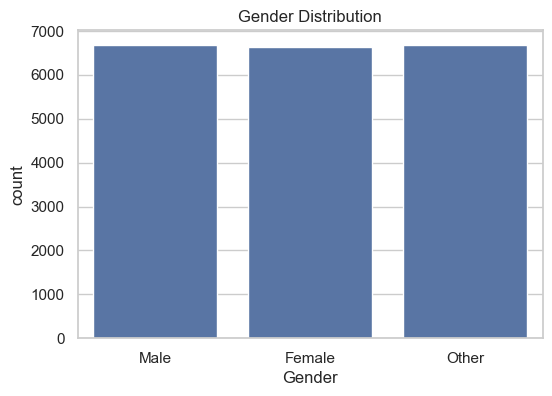

In [14]:
# Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()


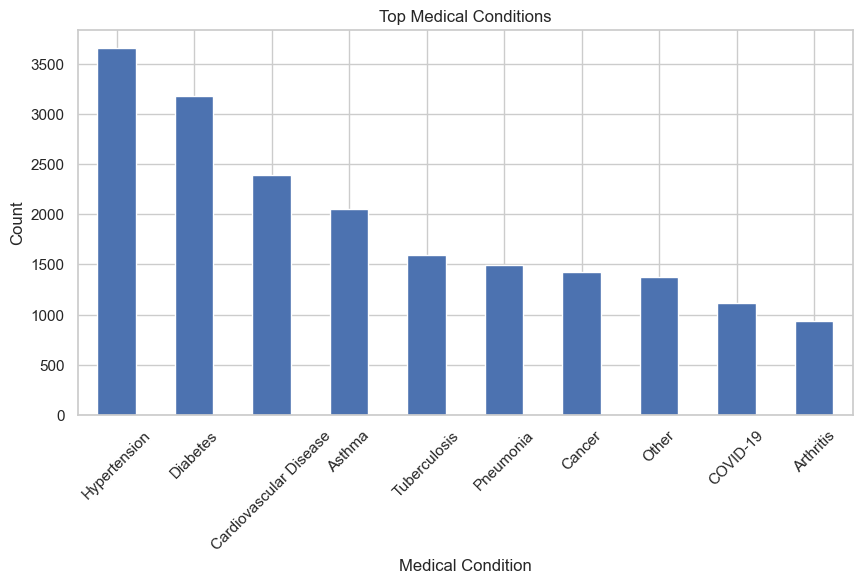

In [16]:
# Top medical conditions
plt.figure(figsize=(10, 5))
df['Medical Condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Medical Conditions")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


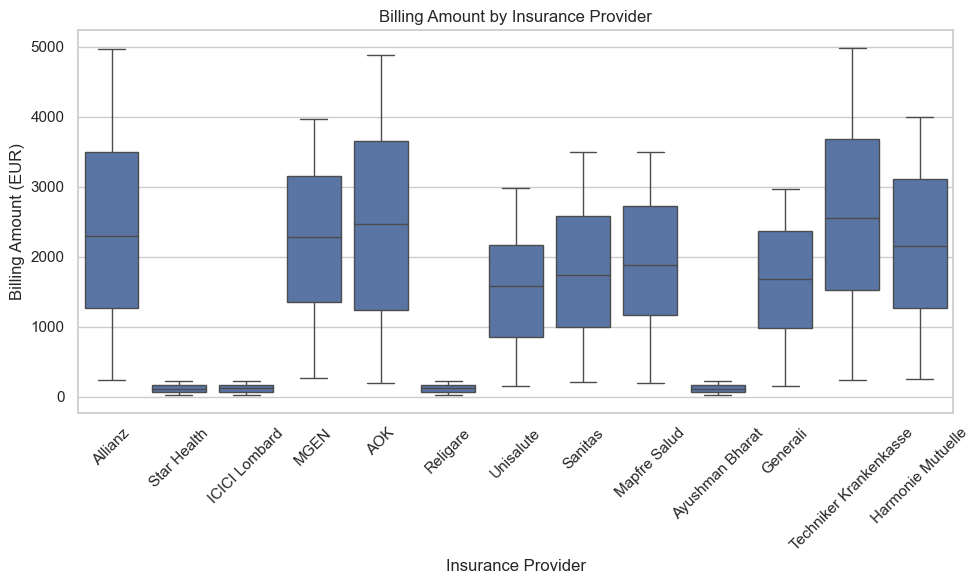

In [124]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Insurance Provider', y='Billing Amount (EUR)', data=df)

plt.title("Billing Amount by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Billing Amount (EUR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

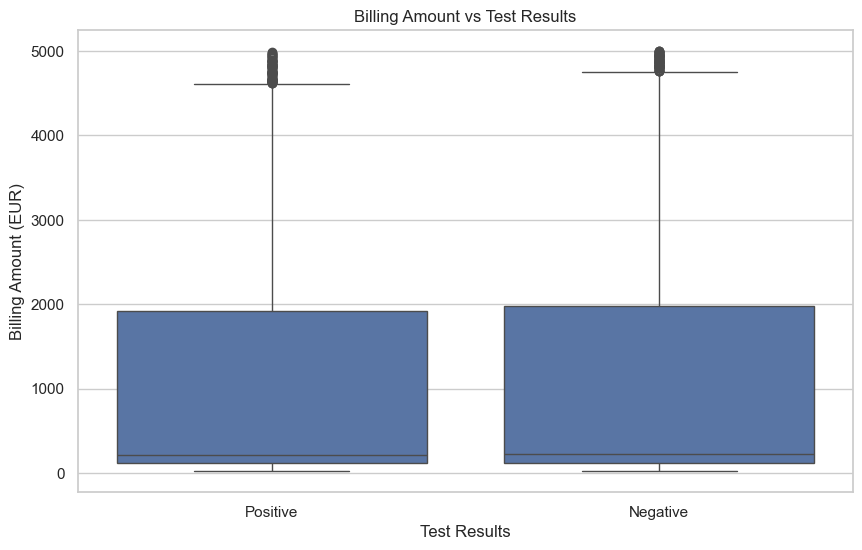

In [18]:
# Billing by test result
plt.figure(figsize=(10, 6))
sns.boxplot(x='Test Results', y='Billing Amount (EUR)', data=df)
plt.title("Billing Amount vs Test Results")
plt.show()


# Step 3: Predictive Modeling

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import category_encoders as ce

# ✅ Load your actual dataset
df = pd.read_csv("C://Applied Project/cleaned_regenerated_healthcare_dataset.csv")

# Drop rows with missing target
df = df.dropna(subset=['Billing Amount (EUR)'])

# Optional: Reduce size for testing (can comment this out for full run)
df = df.sample(5000, random_state=42)

# Separate features and target
X = df.drop(columns=['Billing Amount (EUR)', 'Billing Amount (Local)', 'Billing Currency'])
y = df['Billing Amount (EUR)']

# Identify feature types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing pipeline using TargetEncoder
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', ce.TargetEncoder(), categorical_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=30, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=80, learning_rate=0.1, max_depth=3, random_state=42)
}

# Evaluate each model
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = round(mean_absolute_error(y_test, y_pred), 2)
    r2 = round(r2_score(y_test, y_pred), 4)
    
    print(f"\n{name}")
    print("MAE:", mae)
    print("R² Score:", r2)
    
    results.append({"Model": name, "MAE": mae, "R² Score": r2})

# ✅ Save results
results_df = pd.DataFrame(results)
results_df.to_csv("C://Applied Project/model_evaluation_results.csv", index=False)
print("\n📁 Results saved to: C://Applied Project/model_evaluation_results.csv")



Linear Regression
MAE: 576.11
R² Score: 0.5756

Random Forest
MAE: 508.62
R² Score: 0.5386

Gradient Boosting
MAE: 510.48
R² Score: 0.543

📁 Results saved to: C://Applied Project/model_evaluation_results.csv


# Step 4: Feature Importance (Random Forest)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

# Define categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('Billing Amount (EUR)', axis=1).columns.tolist()

# Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Define the pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor())
])


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df.drop('Billing Amount (EUR)', axis=1)
y = df['Billing Amount (EUR)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))


MAE: 6.817885747026864
R^2: 0.9999004751571026


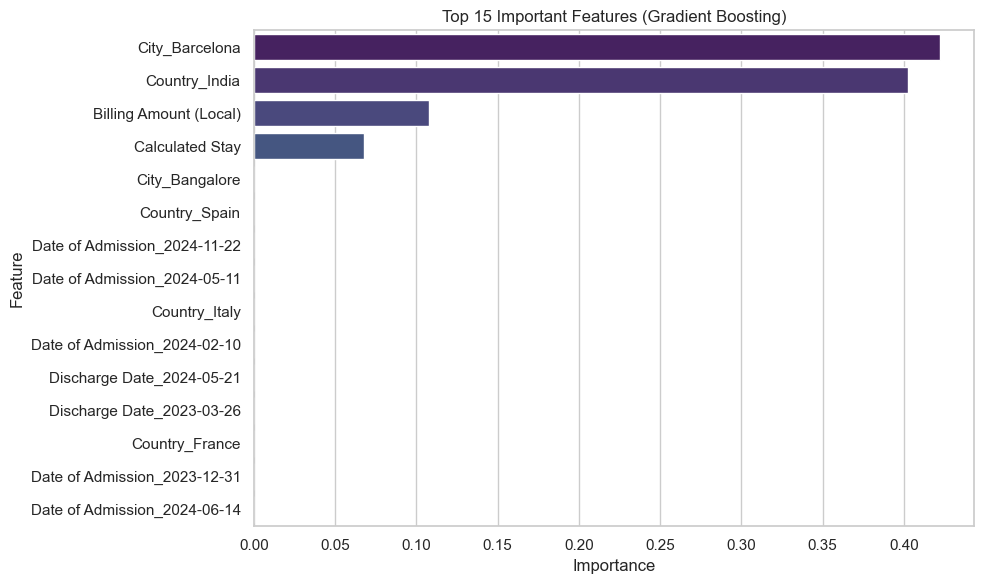

In [26]:
# Get encoded feature names
encoded_categorical_names = model.named_steps['preprocessor'] \
    .named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combine with numeric column names
all_feature_names = list(encoded_categorical_names) + numeric_cols

# Get importances
importances = model.named_steps['regressor'].feature_importances_

# Create DataFrame for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feat_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Important Features (Gradient Boosting)')
plt.tight_layout()
plt.show()


# (Step 5): Save Results + Generate Predictions

In [72]:
import pandas as pd

# Step 5.1: Predict on the full dataset
df['Predicted Billing Amount'] = model.predict(df.drop('Billing Amount (EUR)', axis=1))

# Step 5.2: Save dataframe with predictions
df.to_csv("C://Applied Project/healthcare_predictions_with_actuals.csv", index=False)
print("✅ Saved predictions to: healthcare_predictions_with_actuals.csv")

# Step 5.3: Save model evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score

metrics = {
    'MAE': [mean_absolute_error(y_test, y_pred)],
    'R^2': [r2_score(y_test, y_pred)]
}
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("C://Applied Project/model_evaluation_metrics.csv", index=False)
print("✅ Saved evaluation metrics to: model_evaluation_metrics.csv")


✅ Saved predictions to: healthcare_predictions_with_actuals.csv
✅ Saved evaluation metrics to: model_evaluation_metrics.csv


## Classification of Diagnostic Test Outcomes

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [32]:
# Drop missing values in target column
df_class = df.dropna(subset=['Test Results'])

In [34]:
# Define binary classification target (e.g., Positive/Negative)
df_class['Test_Result_Binary'] = df_class['Test Results'].apply(lambda x: 1 if 'positive' in x.lower() else 0)


In [36]:
# Prepare features and target
X_cls = df_class.drop(columns=['Test Results', 'Test_Result_Binary', 'Billing Amount (EUR)', 
                               'Billing Amount (Local)', 'Billing Currency'])
y_cls = df_class['Test_Result_Binary']

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
from sklearn.pipeline import Pipeline

In [40]:
numerical_cls = X_cls.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cls = X_cls.select_dtypes(include=['object']).columns.tolist()

In [42]:
preprocessor_cls = ColumnTransformer([
    ('num', StandardScaler(), numerical_cls),
    ('cat', ce.TargetEncoder(), categorical_cls)
])

In [44]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

pipeline_cls = Pipeline([
    ('prep', preprocessor_cls),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [46]:
pipeline_cls.fit(X_train_cls, y_train_cls)
y_pred_cls = pipeline_cls.predict(X_test_cls)

print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_cls))

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.48      0.48       495
           1       0.50      0.50      0.50       505

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000

Confusion Matrix:
[[238 257]
 [250 255]]


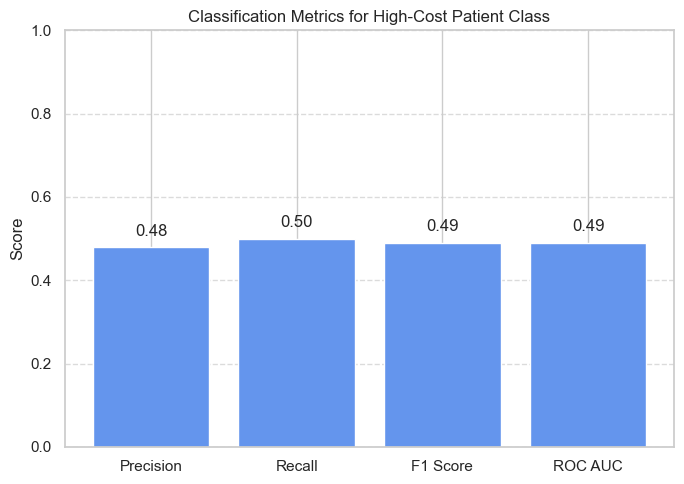

In [126]:
precision = 0.48
recall = 0.50
f1_score = 0.49
roc_auc = 0.49  # (you can calculate this via roc_auc_score(y_test_cls, y_proba_cls) if available)

metrics = ['Precision', 'Recall', 'F1 Score', 'ROC AUC']
values = [precision, recall, f1_score, roc_auc]

# Create bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color='cornflowerblue')
plt.ylim(0, 1.0)
plt.title("Classification Metrics for High-Cost Patient Class")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## High-Cost Patient Classification + SHAP

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap

In [90]:
# Prepare data
df_class = df.dropna(subset=['Billing Amount (EUR)'])
threshold = df_class['Billing Amount (EUR)'].quantile(0.75)
df_class['High_Cost'] = (df_class['Billing Amount (EUR)'] >= threshold).astype(int)

In [92]:
features_cls = ['Age', 'Gender', 'Insurance Provider', 'Medical Condition', 'Test Results']
X_cls = df_class[features_cls]
y_cls = df_class['High_Cost']

In [94]:
numerical_cls = ['Age']
categorical_cls = ['Gender', 'Insurance Provider', 'Medical Condition', 'Test Results']

preprocessor_cls = ColumnTransformer([
    ('num', StandardScaler(), numerical_cls),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cls)
])

pipeline_cls = Pipeline([
    ('prep', preprocessor_cls),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [96]:
# Train model
pipeline_cls.fit(X_train, y_train)
y_pred = pipeline_cls.predict(X_test)
y_proba = pipeline_cls.predict_proba(X_test)[:, 1]

In [98]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", round(roc_auc_score(y_test, y_proba), 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       758
           1       0.58      0.45      0.50       242

    accuracy                           0.79      1000
   macro avg       0.71      0.67      0.68      1000
weighted avg       0.77      0.79      0.78      1000

Confusion Matrix:
[[680  78]
 [134 108]]
ROC AUC Score: 0.84


In [118]:
# ---- SHAP Explanation ----

X_test_transformed = pipeline_cls.named_steps['prep'].transform(X_test)
feature_names = numerical_cls + categorical_cls
X_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)


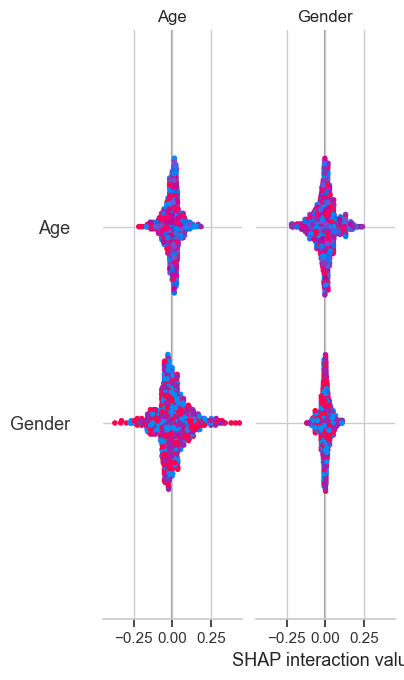

In [120]:
explainer = shap.Explainer(pipeline_cls.named_steps["model"])
shap_values = explainer(X_transformed_df)
shap.summary_plot(shap_values, X_transformed_df)

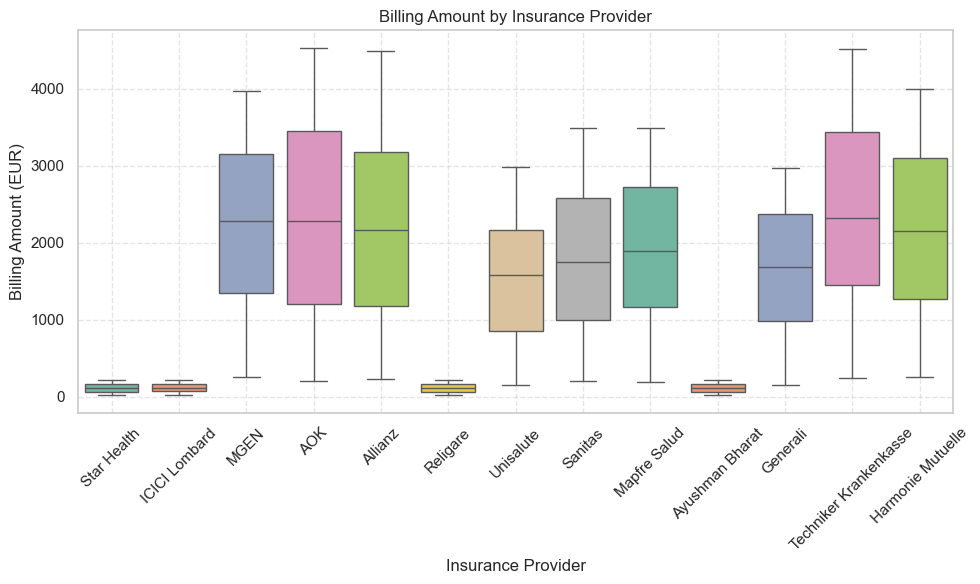

In [128]:
df_plot = df.dropna(subset=['Billing Amount (EUR)', 'Insurance Provider'])

# Optional: remove extreme outliers for better visualization (e.g., 99th percentile)
q99 = df_plot['Billing Amount (EUR)'].quantile(0.99)
df_plot = df_plot[df_plot['Billing Amount (EUR)'] <= q99]

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Insurance Provider', y='Billing Amount (EUR)', palette='Set2')

plt.title('Billing Amount by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount (EUR)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()